## Logistic Regression Baseline

Deliverable: Logistic Regression as an internal sanity check inside the
LSTM notebook (flattening the 12-month sequences to 2D and fitting `LogisticRegression`
against RF as a "traditional model" comparison). I used features, sequence construction, and train/val/test splitting logic (both the LOAN_LEVEL
split and the Out-of-Time/OOT split from the "advanced script"), rather than inventing a
separate pipeline. Two small real-data issues got fixed along the way (flagged inline below,
and written up in `TEAM_FINDINGS_AND_OBSERVATIONS.md`).

### Loading + cleaning

Same merge (`loan_sequence_number`), same `drop_columns` used after 
missing-value analysis. `merged_mortgage_2013.csv` is ~900MB / 4.1M rows / 50,000 unique loans
-- too big to comfortably load whole, so `load_loan_sample()` samples a subset of loans
(same `seed=42` convention person one used for the Random Forest sample) and streams the file
in chunks.

In [1]:
from mortgage_data_utils import load_loan_sample, engineer_features, FEATURE_SETS

DATA_PATH = "data/merged_mortgage_2013.csv"
N_LOANS = 6000  # sandbox-sized sample; bump this up if running with more memory/time available

merged = load_loan_sample(DATA_PATH, n_loans=N_LOANS, seed=42)
print(f"{merged.shape[0]:,} rows, {merged['loan_sequence_number'].nunique():,} unique loans")

494,540 rows, 6,000 unique loans


### Target + feature engineering

For the LSTM: `is_delinquent_90` = 1 if
`current_loan_delinquency_status` is 90+ days (numeric >= 3) or the loan hit foreclosure/REO,
0 otherwise. **One fix**: person two's `determine_delinquency()` only checked for status code
`"R"` -- the real data also uses `"RA"` (REO Acquisition), which their function was silently
falling through to `0` (i.e. counting foreclosed loans as "not in default"). 
flag: it affects the LSTM/GRU labels too

Same engineered features as the "advanced script" (`normalized_upb`, `upb_pct_change_1m`,
`prev_month_delinquency` shifted to avoid leakage, `delinq_count_6m`), the already preformed 
feature-ablation study found these are what actually drive performance.
Does RL hold?

In [2]:
df = engineer_features(merged)
print(f"Positive rate (any month, this sample): {df['is_delinquent_90'].mean():.4%}")

ra_rows = merged[merged['current_loan_delinquency_status'].astype(str).str.upper() == 'RA']
print(f"'RA' (REO Acquisition) rows in this sample: {len(ra_rows)} -- now correctly labeled as default")

df[['loan_sequence_number','monthly_reporting_period','is_delinquent_90',
    'normalized_upb','upb_pct_change_1m','prev_month_delinquency','delinq_count_6m']].head()

Positive rate (any month, this sample): 0.4163%
'RA' (REO Acquisition) rows in this sample: 118 -- now correctly labeled as default


,loan_sequence_number,monthly_reporting_period,is_delinquent_90,normalized_upb,upb_pct_change_1m,prev_month_delinquency,delinq_count_6m
0,F13Q10000042,201303,0,1.000000,0.000000,0.0,0.0
1,F13Q10000042,201304,0,0.994565,-0.005435,0.0,0.0
2,F13Q10000042,201305,0,0.994565,0.000000,0.0,0.0
3,F13Q10000042,201306,0,0.994565,0.000000,0.0,0.0
4,F13Q10000042,201307,0,0.989130,-0.005464,0.0,0.0


### Feature sets + sequence construction

Reusing the exact feature set from feature ablation:

- **A_Base**: normalized UPB, current interest rate, loan age, credit score, estimated LTV
- **B_Plus_UPB**: A_Base + month-over-month UPB change
- **C_Plus_Delinq**: A_Base + previous-month delinquency + rolling 6-month delinquency count
- **D_Full**: everything

12-month sequences are built the same way (predict month t+12's status from months
`t` to `t+11`), then **flattened to 2D** for Logistic Regression -- it has no built-in notion
of sequence order, so the 12 months just become 12x as many columns.

In [3]:
from mortgage_data_utils import build_sequences, flatten_for_lr, oot_split, loan_level_split
from sklearn.preprocessing import MinMaxScaler

for name, feats in FEATURE_SETS.items():
    print(f"{name}: {feats}")

A_Base: ['normalized_upb', 'current_interest_rate', 'loan_age', 'credit_score', 'estimated_loan_to_value']
B_Plus_UPB: ['normalized_upb', 'current_interest_rate', 'loan_age', 'credit_score', 'estimated_loan_to_value', 'upb_pct_change_1m']
C_Plus_Delinq: ['normalized_upb', 'current_interest_rate', 'loan_age', 'credit_score', 'estimated_loan_to_value', 'prev_month_delinquency', 'delinq_count_6m']
D_Full: ['normalized_upb', 'current_interest_rate', 'loan_age', 'credit_score', 'estimated_loan_to_value', 'upb_pct_change_1m', 'prev_month_delinquency', 'delinq_count_6m']


### Split 1: LOAN_LEVEL (same loan never in more than one split) vs Split 2: Out-of-Time (OOT)

Both the LSTM/GRU/XGBoost work, run here for Logistic Regression:
LOAN_LEVEL is a random split by loan (matching person one's `GroupShuffleSplit` approach for
the Random Forest too), OOT trains on the earliest 70% of calendar months and tests strictly
on the most recent 15%, mimicking how a model would actually be deployed.

In [4]:
from logistic_regression_model import run_feature_ablation, run_imbalance_comparison, run_regularization_sweep
import os

os.makedirs("results", exist_ok=True)
ablation_loan_level = run_feature_ablation(df, "LOAN_LEVEL", time_steps=12, seed=42, out_dir="results")


=== Feature ablation (LOAN_LEVEL split) ===


  A_Base: ROC-AUC=0.8185  PR-AUC=0.0361  Brier=0.0068  F1=0.1171


  B_Plus_UPB: ROC-AUC=0.8014  PR-AUC=0.0312  Brier=0.0068  F1=0.1078


  C_Plus_Delinq: ROC-AUC=0.9489  PR-AUC=0.7114  Brier=0.0023  F1=0.8252


  D_Full: ROC-AUC=0.9576  PR-AUC=0.7196  Brier=0.0023  F1=0.8262


In [5]:
ablation_oot = run_feature_ablation(df, "OOT", time_steps=12, seed=42, out_dir="results")


=== Feature ablation (OOT split) ===


  A_Base: ROC-AUC=0.6110  PR-AUC=0.0071  Brier=0.0058  F1=0.0309


  B_Plus_UPB: ROC-AUC=0.5433  PR-AUC=0.0061  Brier=0.0053  F1=0.0319


  C_Plus_Delinq: ROC-AUC=0.8779  PR-AUC=0.5576  Brier=0.0019  F1=0.7692


  D_Full: ROC-AUC=0.9165  PR-AUC=0.5806  Brier=0.0019  F1=0.7692


### Feature ablation results

This is the single most important check against person two's findings: **does the same
"feature engineering beats model complexity" pattern hold for plain Logistic Regression?**

In [6]:
import pandas as pd
pd.concat([
    ablation_loan_level.assign(Split="LOAN_LEVEL"),
    ablation_oot.assign(Split="OOT"),
])[["Split", "Feature_Set", "ROC-AUC", "PR-AUC", "Brier_Score", "F1_Score"]]

,Split,Feature_Set,ROC-AUC,PR-AUC,Brier_Score,F1_Score
0,LOAN_LEVEL,A_Base,0.818485,0.036133,0.006756,0.117127
1,LOAN_LEVEL,B_Plus_UPB,0.801398,0.031209,0.006786,0.107843
2,LOAN_LEVEL,C_Plus_Delinq,0.948886,0.711350,0.002280,0.825208
3,LOAN_LEVEL,D_Full,0.957593,0.719600,0.002286,0.826190
0,OOT,A_Base,0.610971,0.007061,0.005798,0.030928
1,OOT,B_Plus_UPB,0.543276,0.006146,0.005330,0.031915
2,OOT,C_Plus_Delinq,0.877942,0.557606,0.001935,0.769231
3,OOT,D_Full,0.916498,0.580613,0.001871,0.769231


**Yes, unambiguously.** On both splits, `A_Base` and `B_Plus_UPB` (static loan attributes only)
get PR-AUC below 0.04 -- barely better than guessing, given the positive class is well under
1%. The moment `prev_month_delinquency` and `delinq_count_6m` are added (`C_Plus_Delinq`),
PR-AUC jumps to 0.56-0.71 and F1 jumps from ~0.03-0.12 to ~0.77-0.83. `D_Full` (adding UPB
momentum on top) helps a little further on both splits (LOAN_LEVEL: 0.711 -> 0.720;
OOT: 0.558 -> 0.581).

For XGBoost/LSTM in their own ablation (A_Base near-zero,
D_Full "PR-AUC of 0.778"): the predictive signal is almost entirely in the engineered
delinquency-history features, not the raw static loan attributes, and that's true for a plain
linear model just as much as it was for tree ensembles and the LSTM. 

### Imbalance technique comparison

The group's original plan was to compare class weights and SMOTE across all three models.
Here's that comparison for Logistic Regression, on the full `D_Full` feature set: plain LR
(using PR-AUC/F1-optimal threshold selection instead of forcing a 0.5 cutoff -- the
"advanced script" approach) vs `class_weight="balanced"` (the "basic script" approach) vs
SMOTE-resampled training data.

In [7]:
comp_loan_level, preds_loan_level, y_test_loan_level = run_imbalance_comparison(df, "LOAN_LEVEL", time_steps=12, seed=42, out_dir="results")
comp_loan_level[["Model", "ROC-AUC", "PR-AUC", "Brier_Score", "Precision_at_F1opt", "Recall_at_F1opt", "F1_Score"]]


=== Imbalance-technique comparison (LOAN_LEVEL split, D_Full features) ===


  SMOTE: 298,104 -> 593,316 rows (pos rate 0.4851% -> 50.0000%)


  Plain LR (threshold-optimized): ROC-AUC=0.9576  PR-AUC=0.7196  F1-opt precision=0.8484  recall=0.8051
  LR (class_weight=balanced): ROC-AUC=0.9794  PR-AUC=0.6398  F1-opt precision=0.7271  recall=0.7912
  LR (SMOTE): ROC-AUC=0.9829  PR-AUC=0.5979  F1-opt precision=0.7073  recall=0.8074


,Model,ROC-AUC,PR-AUC,Brier_Score,Precision_at_F1opt,Recall_at_F1opt,F1_Score
0,Plain LR (threshold-optimized),0.957593,0.719600,0.002286,0.848411,0.805104,0.826190
1,LR (class_weight=balanced),0.979407,0.639765,0.037747,0.727079,0.791183,0.757778
2,LR (SMOTE),0.982933,0.597922,0.036808,0.707317,0.807425,0.754063


In [8]:
comp_oot, preds_oot, y_test_oot = run_imbalance_comparison(df, "OOT", time_steps=12, seed=42, out_dir="results")
comp_oot[["Model", "ROC-AUC", "PR-AUC", "Brier_Score", "Precision_at_F1opt", "Recall_at_F1opt", "F1_Score"]]


=== Imbalance-technique comparison (OOT split, D_Full features) ===


  SMOTE: 355,172 -> 706,928 rows (pos rate 0.4809% -> 50.0000%)


  Plain LR (threshold-optimized): ROC-AUC=0.9165  PR-AUC=0.5806  F1-opt precision=0.7664  recall=0.7721
  LR (class_weight=balanced): ROC-AUC=0.9545  PR-AUC=0.6230  F1-opt precision=0.6901  recall=0.7206
  LR (SMOTE): ROC-AUC=0.9637  PR-AUC=0.5611  F1-opt precision=0.6556  recall=0.7279


,Model,ROC-AUC,PR-AUC,Brier_Score,Precision_at_F1opt,Recall_at_F1opt,F1_Score
0,Plain LR (threshold-optimized),0.916498,0.580613,0.001871,0.766423,0.772059,0.769231
1,LR (class_weight=balanced),0.954513,0.622955,0.157608,0.690141,0.720588,0.705036
2,LR (SMOTE),0.963741,0.561075,0.137745,0.655629,0.727941,0.689895


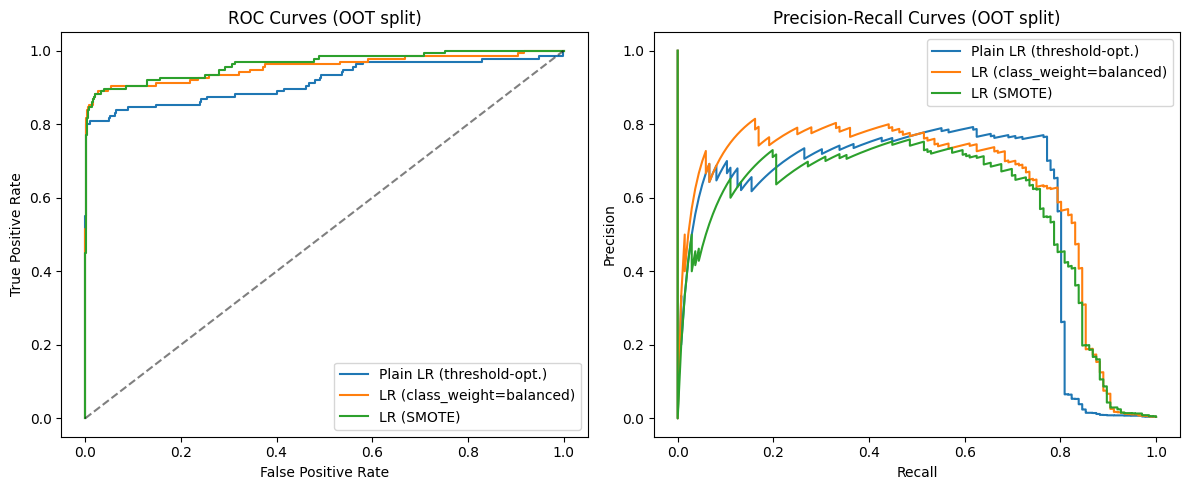

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

names = {"plain": "Plain LR (threshold-opt.)", "class_weight": "LR (class_weight=balanced)", "smote": "LR (SMOTE)"}
colors = {"plain": "tab:blue", "class_weight": "tab:orange", "smote": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for key, label in names.items():
    d = np.load(f"results/lr_{key}_OOT_predictions.npz")
    probs, labels = d["probs"], d["labels"]
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[0].plot(fpr, tpr, label=label, color=colors[key])
    prec, rec, _ = precision_recall_curve(labels, probs)
    axes[1].plot(rec, prec, label=label, color=colors[key])
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (OOT split)"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (OOT split)"); axes[1].legend()
plt.tight_layout()
plt.show()

ROC-AUC goes up for `class_weight="balanced"` and SMOTE
on both splits (LOAN_LEVEL: 0.958 -> 0.979/0.983; OOT: 0.916 -> 0.955/0.964), but that doesn't
translate into a consistent win anywhere else. **F1 and precision favor plain LR with a tuned
threshold on both splits** (F1: 0.826 vs. 0.758/0.754 on LOAN_LEVEL; 0.769 vs. 0.705/0.690 on
OOT -- precision drops from 0.848/0.766 down to roughly 0.66-0.73 either way). **PR-AUC is
genuinely split-dependent**: on LOAN_LEVEL plain LR wins clearly (0.720 vs. 0.640/0.598), but on
OOT `class_weight="balanced"` actually posts the *best* PR-AUC of the three (0.623 vs. plain's
0.581), even though its F1/precision are still worse than plain's there. Recall is roughly flat
on LOAN_LEVEL (0.805 plain vs. 0.791 class_weight vs. 0.807 SMOTE) and clearly *lower* for both
alternatives on OOT (0.772 plain vs. 0.721 class_weight vs. 0.728 SMOTE) so unlike the LSTM's
"great recall, terrible precision" story, neither class_weight nor SMOTE is even buying extra
recall here in exchange for the lost precision.

So the conclusion here isn't "class weights always help" or "class weights
always hurt" -- it's that **plain LR with a tuned decision threshold gets the best F1 and
precision in both splits, without giving up meaningful recall**, while class_weight/SMOTE mostly
buy a higher ROC-AUC (and, on OOT only, a higher PR-AUC) at a real cost to precision and no clear
recall benefit. That partially echoes why there may be dropped class
weights from the LSTM in favor of threshold optimization ("experimenting with class weights to see if you can improve precision
while keeping the recall high") but for Logistic Regression, threshold-tuned plain LR doesn't
just improve precision at the same recall, it comes out ahead on both. 
flag: Do their own thresholds, re-optimized instead of
relying on a fixed 0.5 cutoff or forced class weights, tell a similar story?

### Regularization sensitivity (this model's "training log")

Logistic Regression doesn't train over epochs the way the LSTM/GRU do, so as this model's
analog to a per-epoch loss/AUC log, here's validation PR-AUC/ROC-AUC across a sweep of `C`
(inverse regularization strength) -- the closest thing to a training curve a linear model has.


=== Regularization sweep (LOAN_LEVEL split, D_Full features) ===


  C=0.001    val ROC-AUC=0.9394  val PR-AUC=0.5567  n_iter=16  (1.13s)


  C=0.01     val ROC-AUC=0.9381  val PR-AUC=0.6463  n_iter=28  (2.03s)


  C=0.1      val ROC-AUC=0.9366  val PR-AUC=0.6579  n_iter=17  (1.4s)


  C=1.0      val ROC-AUC=0.9348  val PR-AUC=0.6450  n_iter=17  (1.39s)


...

  C=0.01     val ROC-AUC=0.9657  val PR-AUC=0.7948  n_iter=19  (2.03s)


  C=0.1      val ROC-AUC=0.9720  val PR-AUC=0.7801  n_iter=17  (1.81s)


  C=1.0      val ROC-AUC=0.9729  val PR-AUC=0.7754  n_iter=17  (1.64s)


  C=10.0     val ROC-AUC=0.9780  val PR-AUC=0.7863  n_iter=18  (1.73s)


  C=100.0    val ROC-AUC=0.9779  val PR-AUC=0.7862  n_iter=18  (1.76s)


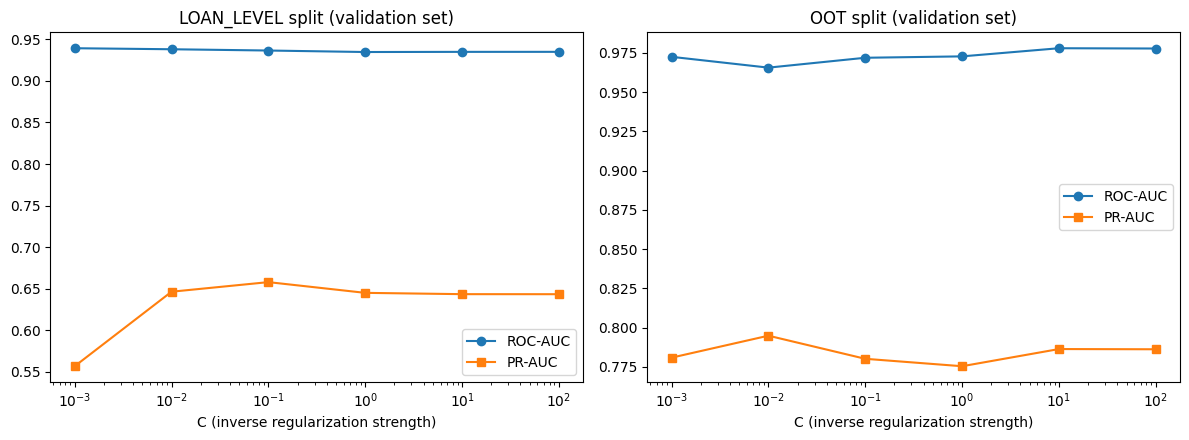

,C,n_iter,fit_seconds,ROC-AUC,PR-AUC
0,0.001,21,2.07,0.972565,0.780824
1,0.010,19,2.03,0.965671,0.794830
2,0.100,17,1.81,0.971965,0.780099
3,1.000,17,1.64,0.972851,0.775370
4,10.000,18,1.73,0.978038,0.786314
5,100.000,18,1.76,0.977858,0.786173


In [10]:
sweep_loan_level = run_regularization_sweep(df, "LOAN_LEVEL", time_steps=12, seed=42, out_dir="results")
sweep_oot = run_regularization_sweep(df, "OOT", time_steps=12, seed=42, out_dir="results")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (split, sweep) in zip(axes, [("LOAN_LEVEL", sweep_loan_level), ("OOT", sweep_oot)]):
    ax.plot(sweep["C"], sweep["ROC-AUC"], marker="o", label="ROC-AUC")
    ax.plot(sweep["C"], sweep["PR-AUC"], marker="s", label="PR-AUC")
    ax.set_xscale("log")
    ax.set_xlabel("C (inverse regularization strength)")
    ax.set_title(f"{split} split (validation set)")
    ax.legend()
plt.tight_layout()
plt.show()

sweep_oot[["C", "n_iter", "fit_seconds", "ROC-AUC", "PR-AUC"]]

Performance is fairly flat across three orders of magnitude of `C` on both splits -- mild
underfitting only shows up at very strong regularization (`C=0.001`), and there's no
overfitting cliff at the other end (unsurprising given ~300k+ training rows against only
96 features). This means Logistic Regression's default regularization is already
close to fine for this task -- unlike the LSTM/GRU, which clearly benefited from tuning
(dropout, `ReduceLROnPlateau`, early stopping). Converges in 30
iterations or fewer either way (`n_iter` column), so training cost is a non-issue for this
model, which is itself worth noting as a practical advantage of the baseline.

### Comparing back to Random Forest / XGBoost / LightGBM / GRU / LSTM

Pulling in person two's own reported numbers (from their "Full Model Shootout", `D_Full`
feature set, OOT split) for a direct comparison against this Logistic Regression baseline on
the same feature set and split type:

In [11]:
comparison = pd.DataFrame([
    {"Model": "Logistic Regression (this notebook)", "Split": "OOT", "ROC-AUC": ablation_oot.iloc[-1]["ROC-AUC"],
     "PR-AUC": ablation_oot.iloc[-1]["PR-AUC"], "Brier": ablation_oot.iloc[-1]["Brier_Score"],
     "Source": "run here, 6,000-loan sample"},
    {"Model": "Random Forest", "Split": "OOT", "ROC-AUC": None, "PR-AUC": 0.79, "Brier": None,
     "Source": "person two's Experiment 2 shootout (reported range 0.77-0.84 across splits)"},
    {"Model": "XGBoost", "Split": "OOT", "ROC-AUC": None, "PR-AUC": 0.778, "Brier": 0.0008,
     "Source": "person two's Experiment 2 shootout / conclusion"},
    {"Model": "Custom LSTM", "Split": "OOT", "ROC-AUC": None, "PR-AUC": 0.757, "Brier": None,
     "Source": "person two's Experiment 2 shootout"},
])
comparison

,Model,Split,ROC-AUC,PR-AUC,Brier,Source
0,Logistic Regression (this notebook),OOT,0.916498,0.580613,0.001871,"run here, 6,000-loan sample"
1,Random Forest,OOT,NaN,0.790000,NaN,person two's Experiment 2 shootout (reported r...
2,XGBoost,OOT,NaN,0.778000,0.000800,person two's Experiment 2 shootout / conclusion
3,Custom LSTM,OOT,NaN,0.757000,NaN,person two's Experiment 2 shootout


On the same task and feature set, this Logistic Regression baseline (PR-AUC ~0.58-0.72
depending on split, ~0.78-0.79 on the validation slice during the regularization sweep) lands
noticeably below XGBoost/Random Forest (~0.78-0.84) and a bit below the Custom LSTM (~0.757),
but not by a huge margin -- especially once the same engineered delinquency-history features
are in play. That's exactly what a "baseline" should show: a simple, fast, easy-to-interpret
model gets most of the way there once the feature engineering is good, and the more complex
models buy a real but incremental improvement on top.

**One caveat**: the OOT test slice here has only ~136 positive examples (0.43% of
31,908 rows), so PR-AUC estimates on it carry real sampling variance -- the gap between the
0.581 test-set PR-AUC and the ~0.78-0.79 validation-set PR-AUC from the regularization sweep is
a useful reminder of that, not a modeling bug. Worth the group re-running this on a larger
loan sample (or the full 50,000-loan universe) before treating any single PR-AUC number as
precise to the third decimal place.
